# 03 — FEct Plot Options (Python)

This notebook showcases FEct plotting options in Python with a clean, web-style narrative. We will:
- Load a demo dataset
- Estimate FEct with and without uncertainty (SE/CI)
- Produce gap (event-study) plots with common options
- Produce calendar-time ATT plots
- Show a status plot (treatment/control/missing across time × units)



In [1]:
# Setup: imports and demo data
# What this cell does:
# - Imports FEct and companion utilities
# - Loads a packaged demo dataset (simdata)
# - Selects core columns Y, D, id, time (+ optional covariates X1/X2)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fect import fect
from fect import data as fdata

sim = fdata.simdata()
req = {"id","time","Y","D"}
if not req.issubset(sim.columns):
    raise ValueError("simdata is missing required columns: id,time,Y,D")

X_cols = [c for c in ["X1","X2"] if c in sim.columns]

df = sim[["id","time","Y","D", *X_cols]].copy()
df.head()


,id,time,Y,D,X1,X2
0,101,1,12.158520,0,1.299638,0.598438
1,101,2,15.083915,0,-0.029369,-0.274701
2,101,3,14.850594,0,-2.236622,0.526919
3,101,4,16.579266,0,0.545030,0.830335
4,101,5,6.784694,0,0.830842,-3.091013


In [2]:
# Estimate FEct: counterfactuals, effects, and (optionally) SE/CI
# What this cell does:
# - Runs FEct without uncertainty (fast preview)
# - Runs FEct with bootstrap uncertainty (SE/CI)

out = fect(
    df, Y="Y", D="D", X=X_cols, index=("id","time"),
    method="fe", se=False,
)
print(out)

out_se = fect(
    df, Y="Y", D="D", X=X_cols, index=("id","time"),
    method="fe", se=True, vartype="bootstrap", nboots=200, seed=123
)
print(out_se)


#> Call:
#>   fect(formula = Y ~ D + X1 + X2, index = ('id', 'time'), force = 'two-way', method = 'fe')
#>
#> ATT:
#>
#>                                    ATT
#>   Tr obs equally weighted        5.121
#>   Tr units equally weighted      3.622
#>
#> Covariates:
#>                                   Coef
#>   X1                             1.015
#>   X2                             2.937
#> Call:
#>   fect(formula = Y ~ D + X1 + X2, index = ('id', 'time'), force = 'two-way', method = 'fe')
#>
#> ATT:
#>
#>                                    ATT    S.E. CI.lower CI.upper p.value
#>   Tr obs equally weighted        5.121  0.3143    4.505    5.737       0
#>   Tr units equally weighted      3.622  0.2643    3.104    4.140       0
#>
#> Covariates:
#>                                   Coef    S.E. CI.lower CI.upper p.value
#>   X1                             1.015 0.03777   0.9412   1.0892       0
#>   X2                             2.937 0.03533   2.8677   3.0062       0


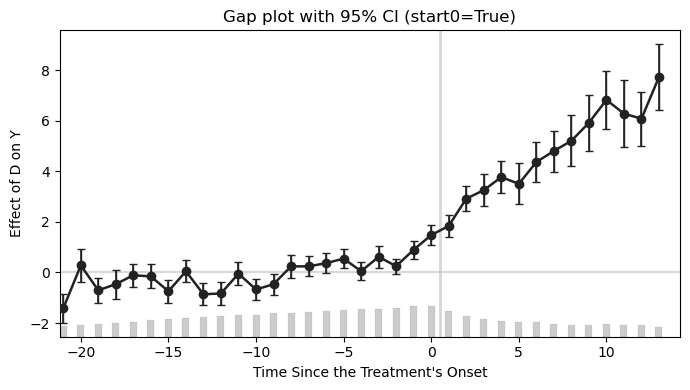

In [3]:
# Gap plot (event study)
# What this cell does:
# - Plots event-time ATT with connected estimates
# - Uses start0=True to shift the first treated period to 0
# - Draws 95% confidence intervals
ax = out_se.plot(type="gap", start0=True, plot_ci="0.95", color="#222222", est_lwidth=1.8)
ax.set_title("Gap plot with 95% CI (start0=True)")
plt.show()


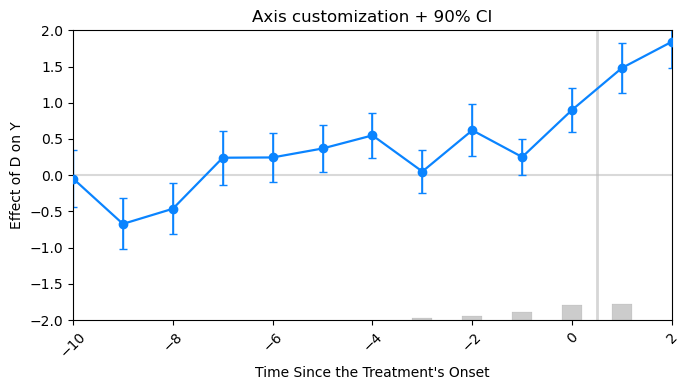

In [4]:
# Axis customization
# What this cell does:
# - Sets x-range and y-range
# - Rotates x tick labels
# - Uses 90% CI for a lighter band
ax = out_se.plot(type="gap", plot_ci="0.9", xlim=(-10, 2), ylim=(-2.0, 2.0),
                 xbreaks=list(range(-10, 3, 2)), xangle=45, color="#0A84FF")
ax.set_title("Axis customization + 90% CI")
plt.show()


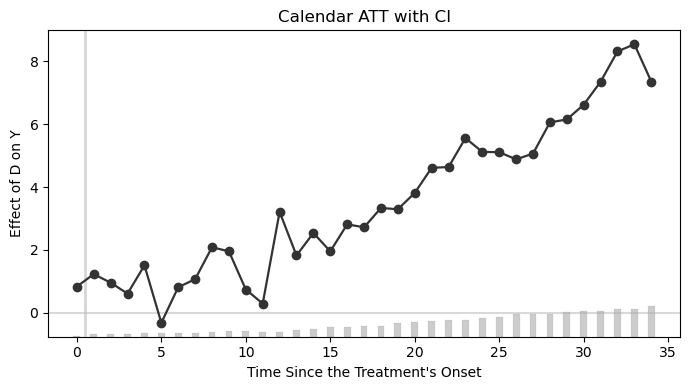

In [5]:
# Calendar plot (calendar-time ATT)
# What this cell does:
# - Aggregates ATT by calendar time
# - Shows confidence intervals if available
ax = out_se.plot(type="calendar", plot_ci="0.95", color="#333333")
ax.set_title("Calendar ATT with CI")
plt.show()


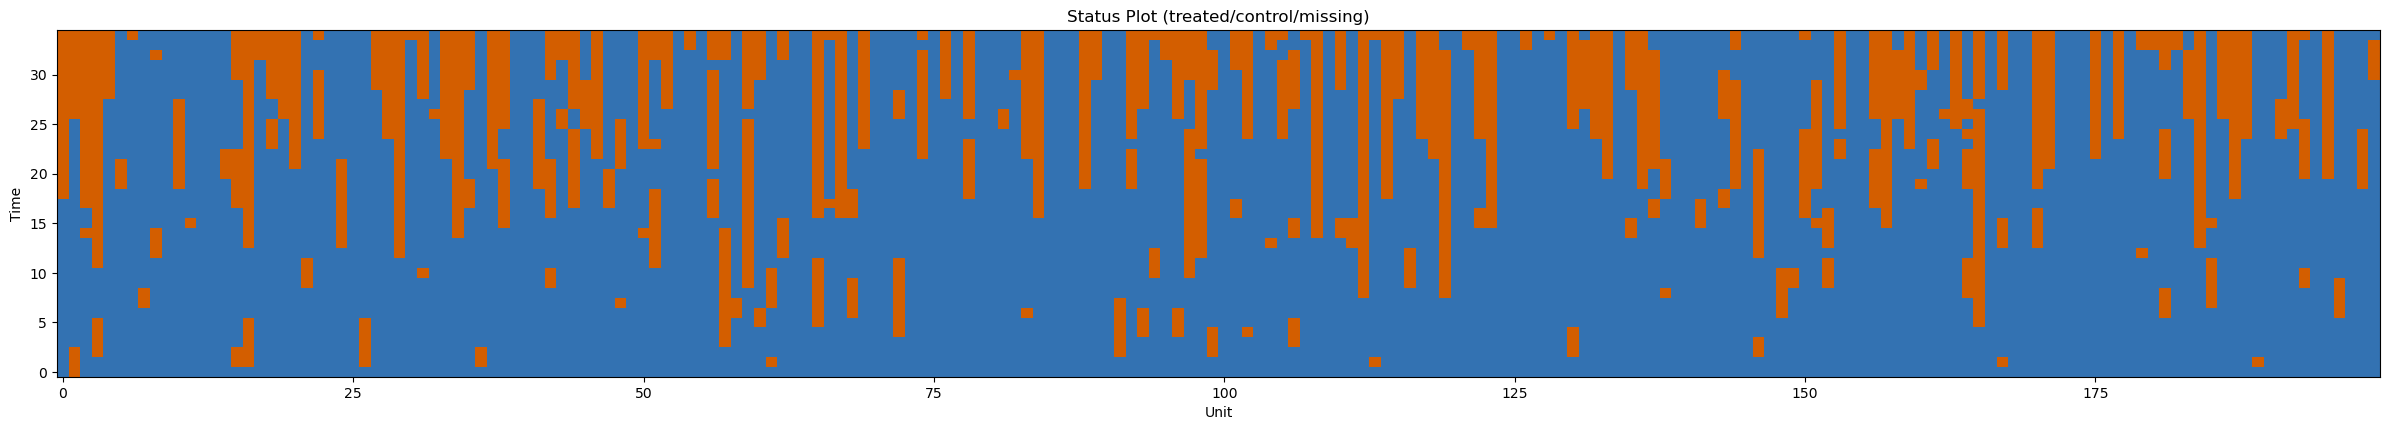

In [6]:
# Status plot — treatment/control/missing by (time × unit)
# What this cell does:
# - Visualizes treatment status for all units over time
# - Colors: treated/control/missing
ax = out.plot(type="status")
ax.set_title("Status Plot (treated/control/missing)")
plt.show()


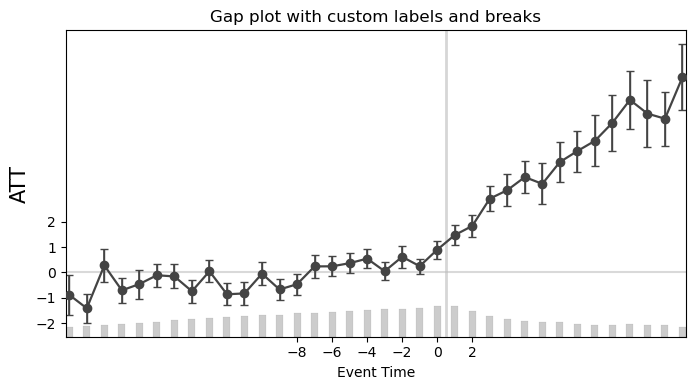

In [7]:
# Gap plot with custom labels and breaks
# What this cell does:
# - Sets x/y axis labels via API
# - Specifies x and y tick breaks
ax = out_se.plot(
    type="gap",
    plot_ci="0.95",
    xlab="Event Time",
    ylab="ATT",
    xbreaks=list(range(-8, 3, 2)),
    ybreaks=[-2.0, -1.0, 0.0, 1.0, 2.0],
    color="#444444",
)
ax.set_title("Gap plot with custom labels and breaks")
plt.show()


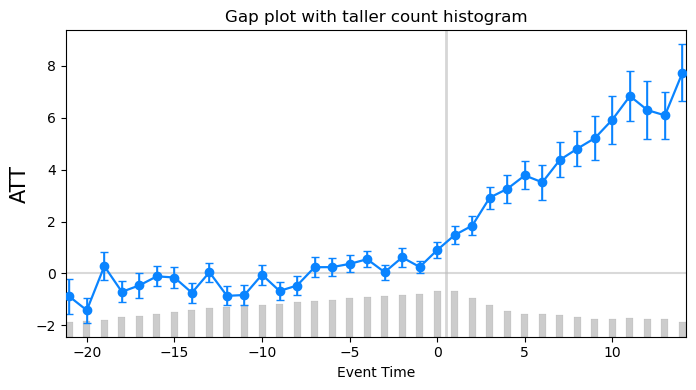

In [8]:
# Gap plot with theme and count histogram height
# What this cell does:
# - Adjusts the count histogram height at the bottom
# - Keeps a neutral theme
ax = out_se.plot(
    type="gap",
    plot_ci="0.9",
    color="#0A84FF",
    est_lwidth=1.6,
    xlab="Event Time",
    ylab="ATT",
    count_height=0.15,  # taller count bars
)
ax.set_title("Gap plot with taller count histogram")
plt.show()


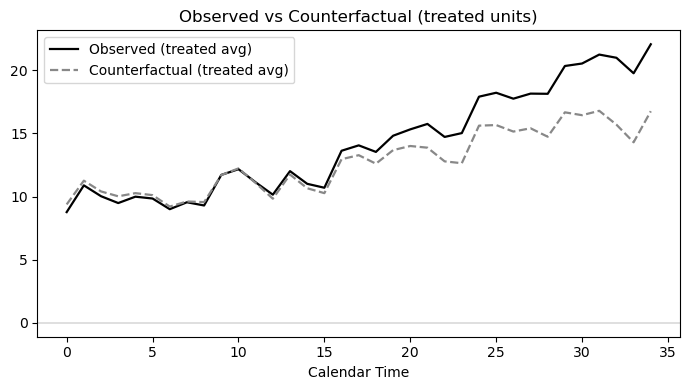

In [9]:
# Counterfactual plot (observed vs counterfactual)
# What this cell does:
# - Compares observed mean outcome among treated vs their counterfactual over time
ax = out_se.plot(type="counterfactual", xlab="Calendar Time")
ax.set_title("Observed vs Counterfactual (treated units)")
plt.show()


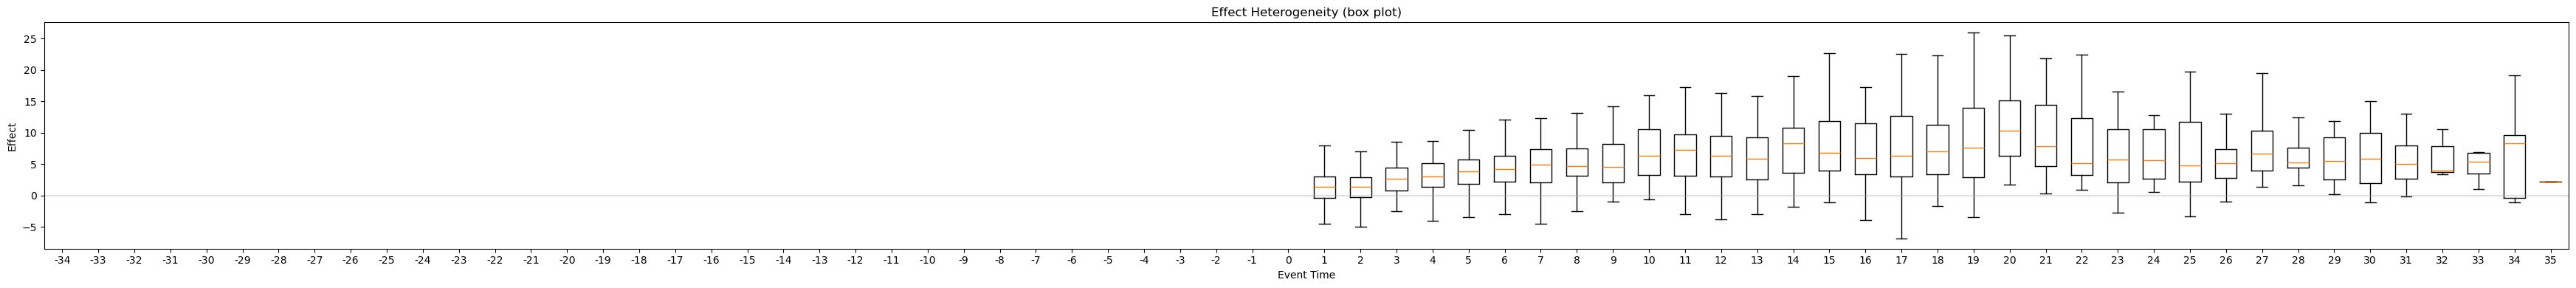

In [10]:
# Box plot: effect heterogeneity by event time
# What this cell does:
# - Shows the distribution of individual effects for each event time
ax = out_se.plot(type="box", xlab="Event Time", ylab="Effect")
ax.set_title("Effect Heterogeneity (box plot)")
plt.show()
